In [5]:

import pandas as pd
from statsmodels.stats.multitest import multipletests
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import json


from matplotlib.lines import Line2D
from matplotlib.patches import Patch


plt.style.use('tableau-colorblind10')
plt.rcParams.update({'font.size': 18, 'font.family':'Arial'})

In [6]:
metadata = pd.read_csv('l_crispatus_inputs/VMGC_metadata.csv', index_col=0)


In [7]:
suffix = 'min_copy_num0.35min_read_count250000.mean_depth5.C75.frequency0.15-0.75.jaccardmax1'

In [8]:

gene_matrix = pd.read_csv(f'l_crispatus_outputs/microSLAM_{suffix}.sample_by_gene_matrix.csv', index_col=0)
df = pd.read_csv(f'l_crispatus_outputs/microSLAM_{suffix}.results.csv')
df = df.rename(columns={'gene_id':'CAG_id'})
cags = pd.read_csv(f'MIDAS_cache/988598/centroid_groupings.{suffix}.csv').set_index('group')['gene'].to_dict()




In [9]:
metadata = metadata.loc[gene_matrix.index]
metadata.value_counts('Group_HC_dysplasia')

Group_HC_dysplasia
HC           82
dysplasia    49
Name: count, dtype: int64

In [10]:
df['odds_ratio'] = np.exp(df['beta'])

df['gene_id'] = df['CAG_id'].map(cags)
df = df.set_index('gene_id')

cag_to_gene = df.reset_index().set_index('CAG_id')['gene_id'].to_dict()
gene_matrix = gene_matrix.rename(columns=cag_to_gene)


df.head()

,CAG_id,tau,cor_to_y,cor_to_b,z,var1,beta,se_beta,t_adj,SPA_pvalue,spa_score,SPA_zvalue,pvalue_noadj,converged,glmm_fdr,odds_ratio
gene_id,,,,,,,,,,,,,,,,
MG334.mbin.2_00182,CAG_14,0,0.285755,-0.307816,3.546164,3.784688,1.822820,0.967976,12.575282,0.000332,6.898805,3.588796,0.000391,True,0.001889,6.189289
ERR10897979.sbin.2_00762,CAG_137,0,0.266256,-0.258729,3.008260,5.299069,1.306820,0.753456,9.049631,0.002496,6.924927,3.023845,0.002627,True,0.028833,3.694405
ERR10897723.sbin.1_00478,CAG_648,0,0.223789,-0.242430,2.793489,3.918721,1.411155,0.844309,7.803580,0.004877,5.529923,2.815062,0.005214,True,0.062058,4.100690
ERR10897595.sbin.1_00593,CAG_215,0,0.221426,-0.216652,2.494366,5.006153,1.114829,0.705875,6.221863,0.012297,5.581003,2.503509,0.012618,True,0.126235,3.049046
SRR17635712.mbin.7_01059,CAG_142,0,0.191288,-0.208610,2.385634,6.868056,0.910305,0.589366,5.691251,0.016924,6.252026,2.388344,0.017050,True,0.147280,2.485081


In [13]:
base_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/code/'

In [15]:
c99_annotations = pd.read_csv(f'{base_dir}/VMGC/VMGC_db/pangenomes/988598/clusters_99_info.tsv', sep='\t', index_col=0)

def add_annotations(row):

    g = row.name

    ann = c99_annotations.loc[g]['Description']
    if pd.isna(ann):
        return '-'
    return ann
    # return ';'.join(c99_annotations.loc[g]['Description'].fillna('-').values)

df['gene_annotations'] = df.apply(add_annotations, axis=1)

### Volcano plot

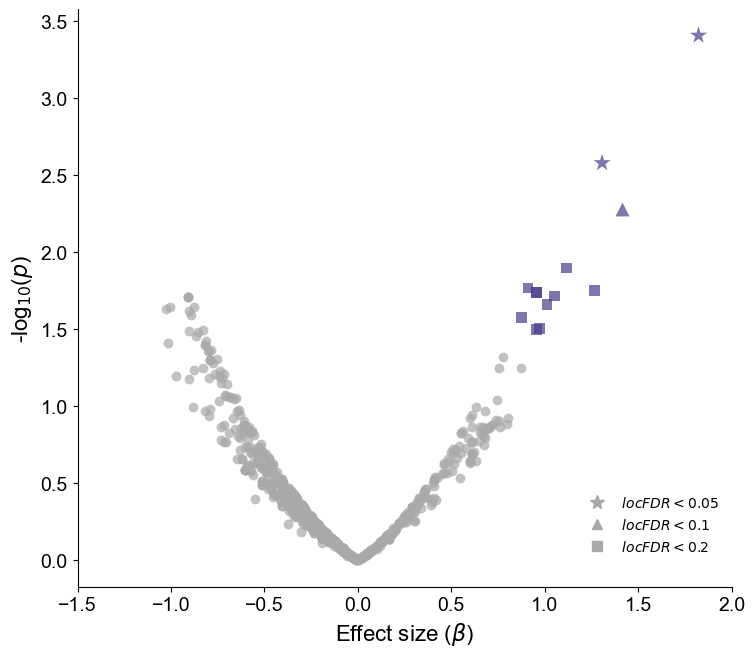

In [52]:

fig, ax = plt.subplots(1,1, figsize=(8.44,7.5))

df['-log10(pvalue_noadj)'] = np.log10(df['pvalue_noadj']) * -1

# sig_05= df[df['glmm_fdr'] < 0.05]

sig = df[df['glmm_fdr'] < 0.2]
sig_05= sig[sig['glmm_fdr'] < 0.05]
sig_10= sig[(sig['glmm_fdr'] >= 0.05) & (sig['glmm_fdr'] < 0.1)]
sig_20= sig[sig['glmm_fdr'] >= 0.1]


not_sig = df[df['glmm_fdr'] >= 0.2]
sig_genes = sig.index.tolist() 
sig_cags = sig['CAG_id'].tolist()


sns.scatterplot(x=sig_05['beta'], y=sig_05['-log10(pvalue_noadj)'], s=170, hue=sig_05['beta']>0, 
                palette=['darkslateblue'], legend=False,  linewidth=0, marker='*', ax=ax, alpha=.7)

# sig_10 = sig.loc[[i for i in sig.index if i not in sig_05.index]]
sns.scatterplot(x=sig_10['beta'], y=sig_10['-log10(pvalue_noadj)'], s=100, hue=sig_10['beta']>0, 
                palette=['darkslateblue'], legend=False,  linewidth=0, marker='^', ax=ax, alpha=.7)

# sig_20 = sig.loc[[i for i in sig.index if i not in sig_05.index and i not in sig_10.index]]
sns.scatterplot(x=sig_20['beta'], y=sig_20['-log10(pvalue_noadj)'], s=60, hue=sig_20['beta']>0, 
                palette=['darkslateblue'], legend=False,  linewidth=0, marker='s', ax=ax, alpha=.7)

sns.scatterplot(x=not_sig['beta'], y=not_sig['-log10(pvalue_noadj)'], s=50, color='darkgrey', 
                legend=False, linewidth=0, alpha=0.7, ax=ax)
    
ax.spines[['right', 'top']].set_visible(False)
plt.tick_params(axis='x', labelsize=14)          
plt.tick_params(axis='y', labelsize=14)      
ax.set_xlabel(r'Effect size ($\beta$)', fontsize=16)
ax.set_ylabel(r'-log$_{10}$($\it{p}$)', fontsize=16)
# ax.set_ylim(-0.05, 3)
ax.set_xlim(-1.5, 2)

# Add custom legend
legend_element_05 = Line2D([0], [0], marker='*', color='darkgrey', linestyle='None',
                        markersize=10, label=' '+r'$\it{locFDR} < 0.05$', )
legend_element_10 = Line2D([0], [0], marker='^', color='darkgrey', linestyle='None',
                        markersize=7, label=' '+r'$\it{locFDR} < 0.1$', )
legend_element_20 = Line2D([0], [0], marker='s', color='darkgrey', linestyle='None',
                        markersize=7, label=' '+r'$\it{locFDR} < 0.2$', )
ax.legend(handles=[legend_element_05, legend_element_10,legend_element_20 ], frameon=False, bbox_to_anchor=(1,0.18), fontsize=10, handletextpad=0.5)


fig_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f'{fig_dir}/figure_4A.png', format='png', dpi=600, bbox_inches="tight")
plt.show()



In [32]:
gene_matrix[sig_genes].sum()/gene_matrix[sig_genes].shape[0]

MG334.mbin.2_00182          0.167939
ERR10897979.sbin.2_00762    0.274809
ERR10897723.sbin.1_00478    0.175573
ERR10897595.sbin.1_00593    0.244275
SRR17635712.mbin.7_01059    0.488550
ERR10898139.sbin.1_00313    0.152672
ERR10897595.sbin.1_01051    0.343511
ERR10897583.sbin.2_00776    0.343511
ERR10897583.sbin.2_00437    0.244275
ERR4421622.sbin.2_01193     0.251908
ERR10897595.sbin.1_00591    0.381679
ERR10897595.sbin.1_00598    0.236641
ERR10897696.sbin.1_01201    0.251908
dtype: float64

### Save sequences of hits to file

In [33]:
to_write = ''
for r in SeqIO.parse(f'{base_dir}/VMGC/VMGC_db/pangenomes/988598/centroids_95.ffn', 'fasta'):
    
    if r.id in sig_genes:

        to_write += f'>{r.id}\n{r.seq}\n'


with open('signficant_gene_seqs.fna', 'w') as f:
    f.write(to_write)

In [34]:
!cat signficant_gene_seqs.fna

>MG334.mbin.2_00182
ATGACTGAAGATGCAAAACTAAAGCAAGTAATGAATAAAATTAATGATGCAATTAGTTGGATTAAGCAGCTAAACTGTATTGTGCCTAATTCTATAAATACTGAATTAAATCCTGATGACGGCAGTGTCTTGCTTTACTTACAAACGCCAAATAACTTAATTGTGCCTAGTTTACTTTTGAACGTGCAAACTTATGACTACTTGCTTGAGCAAGATGATGCTTCTAACGGCGAGGGGATTGTTATTAGTTGGGCTGGCAGTTTTATGGATGCCACGGCGCCAAAAGAGAGGACCGGGCTTGATCCGGAGCAATTGCGCCAAGATATGGATTATTTGTGCAATGTCTGGTATAAATTGACTAAGCAAAGTGAAGCGATTAATGATTATTATCAAGATACAGCTGATTTGTCTGCTGAAAAGATCAAGGCAGAATTGCAACAGATTTTAACTACAAGCGGTGTGTTTGACGCTGATGTATTAGCTGATGTATTAGCCGAAACTGAAACGCAGCTAGCAGGGATGCCGTTTGCTTATCTATGGGGAATTTATCAAGAAGTGCAACGTTCAGCTAGTGATAATAAAACTGCAGGACAACTGCTTTACCACTTGGCAGTCGAGATTCCTCATGATTCCTATTTGTTCAAGCCAGATCCTAATTTTTCTTTATTAGCTAATTTATCTGCTCAAGCTGCAGCAACTAGTGATGCTCCTGATTTGATGGGTGAGCCAATTGAGCGAGCAGAAGCAGAAAAAATGGTAAAAAAATTACACCAGGCTGGTGAATTATTGGTTGAAAATAATTTGATTCCTGCTGGCGCTTTGGGCGTAGAATACGATGAAACGCAACATGATGTAATTGTCTATCTGCAGTCACCTAATGACGTGATGATTTTCCGTAATGATATTCTGGGTACCAAAACTGCGGCAATGATTGAGCAGGAGAATGCCGAGCAGTGCGCAGCTCATATTGCTATTTCATT

### Extract annotations from BLAST results

In [35]:
ann_dict = {}

!cat BLAST_annotations/*-Alignment.txt > BLAST_annotations/combined.txt
for i in sig_genes:
    lines = !grep {i} -A 14 BLAST_annotations/combined.txt
    desc_idx = [i for i,l in enumerate(lines) if l.startswith('Description')]
    if len(desc_idx) == 0 or len(lines) == desc_idx[0]+1:
        continue
    desc_lines = lines[desc_idx[0]+1:]
    ann = set([g.split('         ')[0].split('[')[0].replace('MULTISPECIES: ','').replace('...','').replace('Lactobacillus   NA', '').replace('Lactobacillu NA', '').strip(' ')
                  for g in desc_lines])
    ann_dict[i] =  ';'.join(ann)



In [36]:
[i for i in sig_genes if i not in ann_dict.keys()]

[]

In [37]:
ann_dict

{'MG334.mbin.2_00182': 'hypothetical protein',
 'ERR10897979.sbin.2_00762': 'hypothetical protein;hypothetical protein C3K22_05480;hypothetical protein HMPREF0507_02012',
 'ERR10897723.sbin.1_00478': 'type II toxin-antitoxin system HicA family toxin;type II toxin-antitoxin system HicA family toxin, partial',
 'ERR10897595.sbin.1_00593': 'hypothetical protein',
 'SRR17635712.mbin.7_01059': 'Na+/H+ antiporter NhaC',
 'ERR10898139.sbin.1_00313': 'hypothetical protein HMPREF5045_00853;LacI family transcriptional regulator;Transcriptional regulator, repressor of sugar transport operon;LacI family DNA-binding transcriptional regulator;substrate-binding domain-containing protein',
 'ERR10897595.sbin.1_01051': 'hypothetical protein CEE83_12135;hypothetical protein;hypothetical protein C3K22_05490',
 'ERR10897583.sbin.2_00776': 'hypothetical protein',
 'ERR10897583.sbin.2_00437': 'type II toxin-antitoxin system HicB family antitoxin;type II toxin-antitoxin system HicB family;type II toxin-antit

In [38]:
ann_dict_simple = {'MG334.mbin.2_00182': 'hypothetical protein (1)',
 'ERR10897979.sbin.2_00762': 'hypothetical protein (2)',
 'ERR10897595.sbin.1_00593': 'hypothetical protein (3)',
 'ERR10897723.sbin.1_00478': 'type II toxin-antitoxin system HicA family toxin',
 'ERR4421622.sbin.2_01193': 'XRE family transcriptional regulator',
 'SRR17635712.mbin.7_01059': 'Na+/H+ antiporter NhaC',
 'ERR10897595.sbin.1_01051': 'hypothetical protein (4)',
 'ERR10897583.sbin.2_00776': 'hypothetical protein (5)',
 'ERR10897696.sbin.1_01201': 'DUF771 domain-containing protein',
 'ERR10897595.sbin.1_00598': 'hypothetical protein (6)',
 'ERR10898139.sbin.1_00313': 'LacI family transcriptional regulator',
 'ERR10897595.sbin.1_00591': 'MarR family transcriptional regulator',
  'ERR10897583.sbin.2_00437': 'type II toxin-antitoxin system HicB family antitoxin',
 }


In [39]:
sig['BLAST_annotation'] = sig.index.map(ann_dict_simple)


pd.set_option("display.max_colwidth", None)  

sig[['beta', 'glmm_fdr', 'BLAST_annotation']].sort_values('beta')

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_14099/1067504282.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sig['BLAST_annotation'] = sig.index.map(ann_dict_simple)


,beta,glmm_fdr,BLAST_annotation
gene_id,,,
ERR10897595.sbin.1_00591,0.874454,0.173849,MarR family transcriptional regulator
SRR17635712.mbin.7_01059,0.910305,0.147280,Na+/H+ antiporter NhaC
ERR10897696.sbin.1_01201,0.954419,0.184096,DUF771 domain-containing protein
ERR10897595.sbin.1_01051,0.954488,0.151226,hypothetical protein (4)
ERR10897583.sbin.2_00776,0.954488,0.151226,hypothetical protein (5)
ERR10897595.sbin.1_00598,0.970202,0.183124,hypothetical protein (6)
ERR4421622.sbin.2_01193,1.011564,0.161808,XRE family transcriptional regulator
ERR10897583.sbin.2_00437,1.051643,0.153942,type II toxin-antitoxin system HicB family antitoxin
ERR10897595.sbin.1_00593,1.114829,0.126235,hypothetical protein (3)


### Gene group frequency plots

In [40]:
gene_matrix = gene_matrix[sig_genes]
gene_matrix['outcome'] = gene_matrix.index.map(metadata['outcome'])

In [41]:

present_counts = gene_matrix.groupby('outcome').sum()
total_counts = gene_matrix.groupby('outcome').count()
absent_counts = total_counts[sig_genes] - present_counts[sig_genes]

present_counts = present_counts[sig_genes].add_suffix('_present')
absent_counts = absent_counts[sig_genes].add_suffix('_absent')

result = pd.concat([present_counts, absent_counts], axis=1)

props = result.div(gene_matrix['outcome'].value_counts(), axis=0)


In [42]:
sig_genes = sig.index.tolist()
sig_genes_reordered = sig.sort_values(['beta',]).index.tolist()
len(sig_genes)

13

In [43]:
gene_order = sig.sort_values('beta', ascending=False).index.tolist()

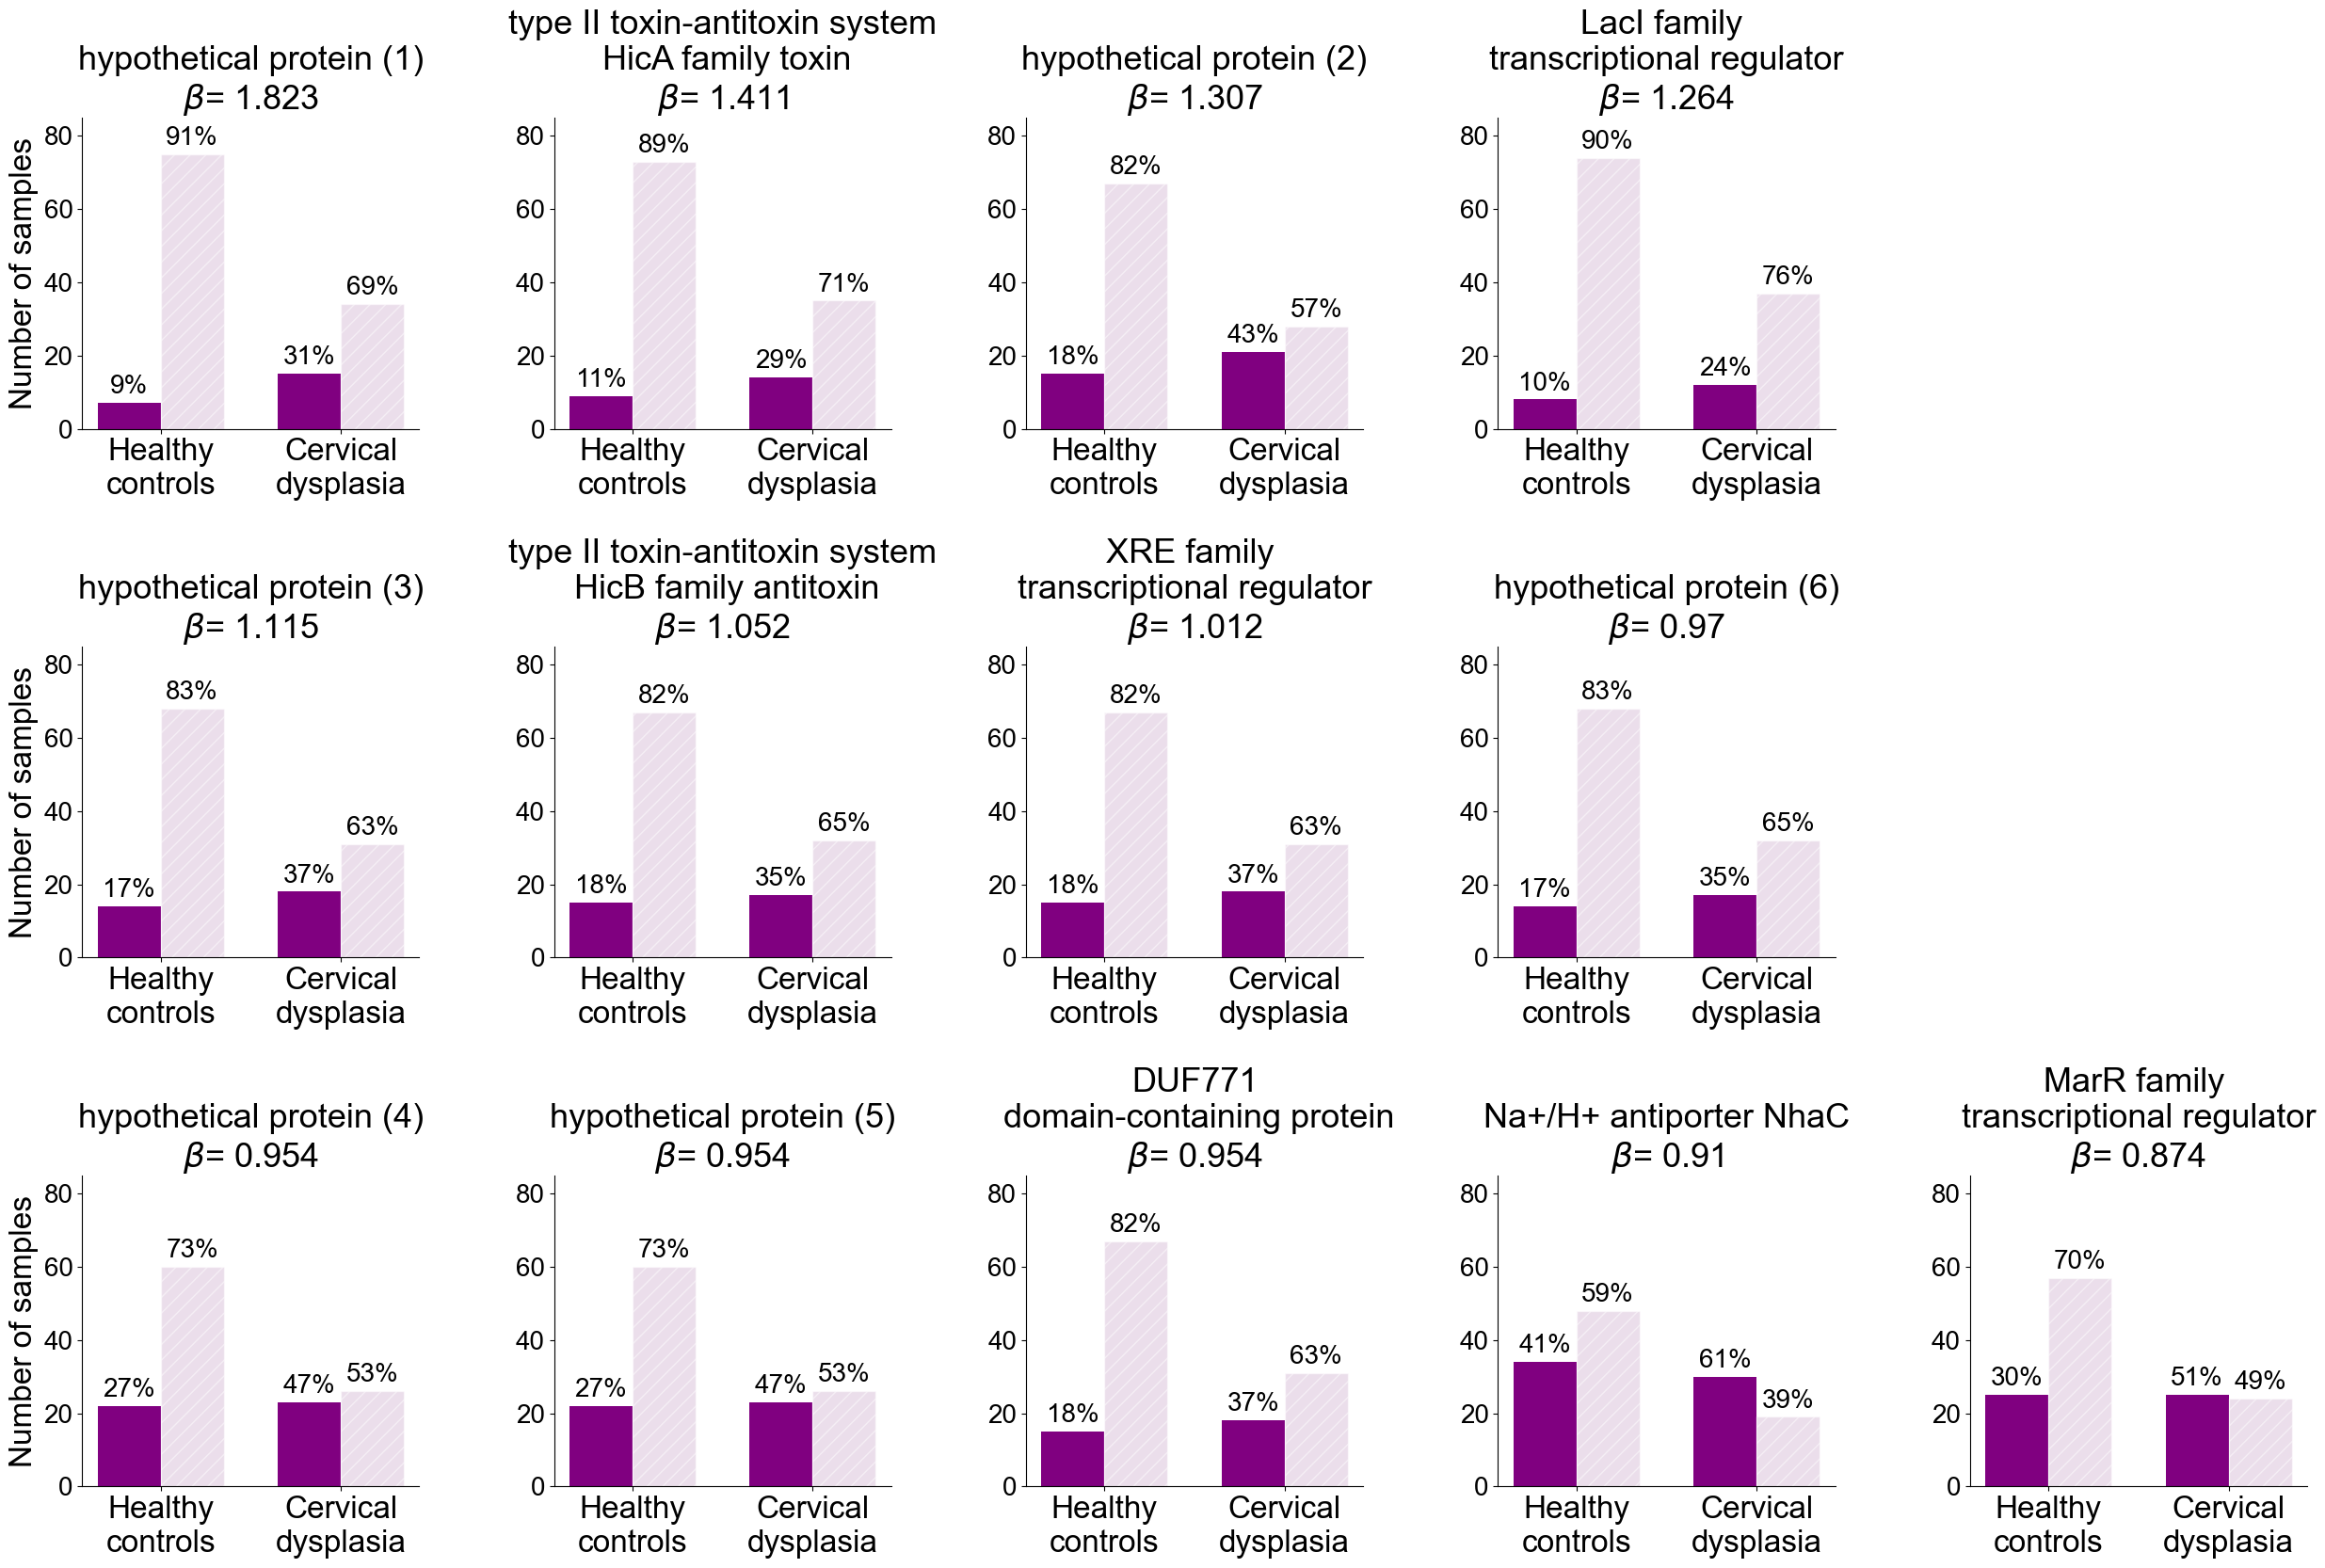

In [44]:


gene_order = sig.sort_values('beta').index.tolist()

gene_order = ['MG334.mbin.2_00182',
 'ERR10897723.sbin.1_00478',
 'ERR10897979.sbin.2_00762',
 'ERR10898139.sbin.1_00313',
 'skip', #blank plot for spacing
 'ERR10897595.sbin.1_00593',
 'ERR10897583.sbin.2_00437',
 'ERR4421622.sbin.2_01193',
 'ERR10897595.sbin.1_00598',
 'skip', #blank plot for spacing
 'ERR10897595.sbin.1_01051',
 'ERR10897583.sbin.2_00776',
 'ERR10897696.sbin.1_01201',
 'SRR17635712.mbin.7_01059',
 'ERR10897595.sbin.1_00591']

colors = {
    'present': 'purple',
    'absent': 'thistle'
}

fig, axes = plt.subplots(3, 5, figsize=(25,17
))
bar_width = 0.35  
plt.subplots_adjust(wspace=0.5, hspace=0.5)

outcomes = [0,1]
x = np.arange(len(outcomes)) 
j = 0

for ax, gene in zip(axes.reshape(-1), gene_order):

    if gene == 'skip':
        ax.axis('off')

        continue

    present_counts = [result.loc[outcome, f'{gene}_present'] for outcome in outcomes]
    absent_counts = [result.loc[outcome, f'{gene}_absent'] for outcome in outcomes]
    total_counts = [present + absent for present, absent in zip(present_counts, absent_counts)]

    # Plot gene present bars
    ax.bar(x - bar_width/2, present_counts, width=bar_width, color=colors['present'], label='Gene present')

    # Plot gene absent bars
    ax.bar(x + bar_width/2, absent_counts, width=bar_width, edgecolor='white', hatch='//', color=colors['absent'], alpha=0.5, label='Gene absent')

    # Add proportion annotations
    for i in range(len(outcomes)):
        present_pct = 100 * present_counts[i] / total_counts[i]
        absent_pct = 100 * absent_counts[i] / total_counts[i]
        ax.text(x[i] - bar_width/2, present_counts[i] + 1, f'{present_pct:.0f}%', ha='center', va='bottom', fontsize=20)
        ax.text(x[i] + bar_width/2, absent_counts[i] + 1, f'{absent_pct:.0f}%', ha='center', va='bottom', fontsize=20)

    # Set labels and title
    gene_p = sig.loc[gene]['glmm_fdr']
    gene_OR = sig.loc[gene]['odds_ratio']
    gene_beta = round(sig.loc[gene]['beta'],3)

    gene_ann = ann_dict_simple[gene]
    if 'Hypothetical protein' in gene_ann:
        gene_ann = 'Hypothetical protein'
    if 'toxin' in gene_ann:
        gene_ann = gene_ann.replace('system', 'system\n')
    if 'helix' in gene_ann:
        gene_ann = 'helix-turn-helix\ndomain-containing protein'
    if 'transcriptional' in gene_ann:
        gene_ann = gene_ann.replace('transcriptional', '\ntranscriptional')
    if 'DUF771' in gene_ann:
        gene_ann = gene_ann.replace('DUF771', 'DUF771\n')
    if 'toxin' in gene_ann:
        fontsize=26
    else:
        fontsize=26
    ax.set_title(f'{gene_ann}\n' +r'$\beta$' +f'= {gene_beta}', fontsize=fontsize)

    ax.set_xticks(x)
    ax.set_xticklabels(['Healthy\ncontrols', 'Cervical\ndysplasia'], fontsize=24)
    ax.spines[['right', 'top']].set_visible(False)
    if j in [0,4,8]:
        ax.set_ylabel('Number of samples', fontsize=24)
    j+=1

    

    ax.set_ylim(0,85)
    ax.set_yticks([0,20,40,60,80],[0,20,40,60,80], fontsize=20)


plt.tight_layout()
plt.subplots_adjust(wspace=0.4, hspace=0.7)
fig_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f'{fig_dir}/figure_4C.png', format='png', dpi=600, bbox_inches="tight")

plt.show()


### Presence/absence heat map

In [45]:
dys_samples = gene_matrix[gene_matrix['outcome'] == 1][[col for col in gene_matrix.columns if col not in ['outcome','study']]]
dys_sample_order = dys_samples.sum(axis=1).sort_values().index.to_list()

hc_samples = gene_matrix[gene_matrix['outcome'] == 0][[col for col in gene_matrix.columns if col not in ['outcome','study']]]
hc_sample_order = hc_samples.sum(axis=1).sort_values().index.to_list()

sample_order = dys_sample_order + hc_sample_order[::-1]

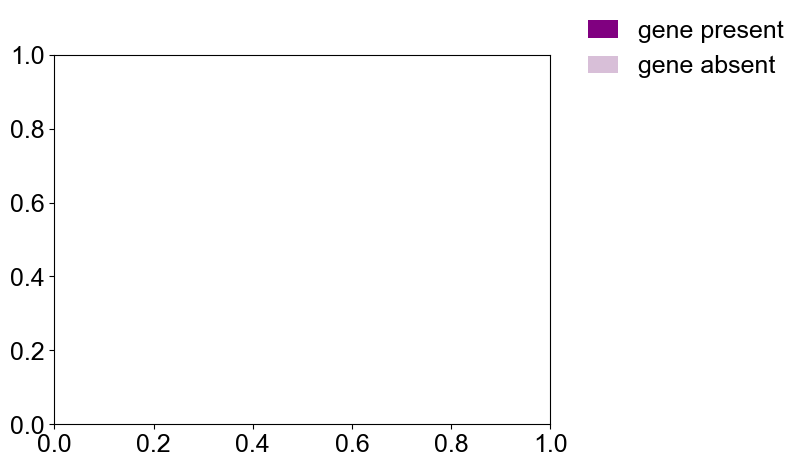

In [46]:
legend_elements = [
    Patch(facecolor='purple',  label='gene present'),

    Patch(facecolor='thistle',  label='gene absent'),
]

# Create a blank figure and add the legend
plt.legend(handles=legend_elements, ncols=1, frameon=False,
           bbox_to_anchor=(1.3, 1), bbox_transform=plt.gcf().transFigure,
            fontsize=18, loc='upper right', handlelength=1.2, columnspacing=1.5)

plt.savefig(f'{fig_dir}/figure_4_legend.png', format='png', dpi=600,bbox_inches = "tight")

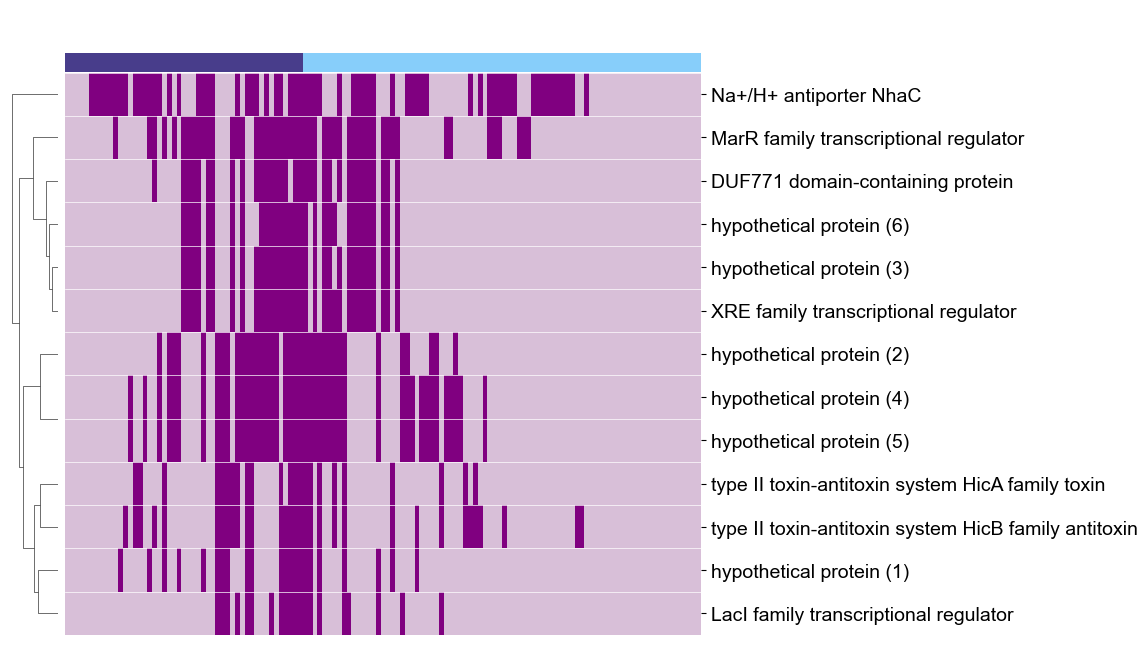

In [47]:
plt.style.use('tableau-colorblind10')
plt.rcParams.update({'font.size': 14, 'font.family':'Arial'})


temp = gene_matrix

temp = temp.loc[sample_order]
to_plot = temp[[col for col in temp.columns if col not in ['outcome','study']]]
lut = dict(zip([0,1], ['lightskyblue','darkslateblue']))
outcome_row_colors = temp['outcome'].map(lut)

g = sns.clustermap(to_plot.T,
                    dendrogram_ratio=0.07, cbar_pos=None, figsize=(10, 8),
                    # col_linkage=link,
                                  # row_colors=[outcome_row_colors],

              col_colors=[outcome_row_colors, ],
              col_cluster=False,
                  #  row_colors=row_colors,
                   cmap=['thistle','purple'],yticklabels=1,
                  linewidths=0.002, 
                  colors_ratio=0.03,)

for i in range(temp.shape[1]-1): # Iterate through columns
            plt.axhline(y=i, color='white', linestyle='-', linewidth=0.5)

g.ax_heatmap.set_yticklabels([ann_dict_simple[x.get_text().split(' (')[0]] for x in g.ax_heatmap.get_yticklabels()], rotation=0)

box_heatmap = g.ax_heatmap.get_position()

handles = [Patch(facecolor=lut[name]) for name in lut]

plt.xlabel('')
plt.ylabel('')

plt.xticks([])


plt.savefig(f'{fig_dir}/figure_4B.png', format='png', dpi=600,bbox_inches = "tight")
plt.show()

In [48]:
from scipy.spatial.distance import pdist, squareform

binary = (to_plot.values > 0).astype(int)

dists = squareform(pdist(binary.T, metric="jaccard"))
colnames = [ann_dict_simple[c] for c in to_plot.columns]

dists = pd.DataFrame(1-dists, index=colnames, columns=colnames)

dists_min_80 = dists >= 0.8

for col in dists.columns:

    temp = dists_min_80[col].drop(col)
    print(f'{col}: {temp[temp == True].index.tolist()}')


hypothetical protein (1): []
hypothetical protein (2): ['hypothetical protein (4)', 'hypothetical protein (5)']
type II toxin-antitoxin system HicA family toxin: []
hypothetical protein (3): ['XRE family transcriptional regulator', 'hypothetical protein (6)', 'DUF771 domain-containing protein']
Na+/H+ antiporter NhaC: []
LacI family transcriptional regulator: []
hypothetical protein (4): ['hypothetical protein (2)', 'hypothetical protein (5)']
hypothetical protein (5): ['hypothetical protein (2)', 'hypothetical protein (4)']
type II toxin-antitoxin system HicB family antitoxin: []
XRE family transcriptional regulator: ['hypothetical protein (3)', 'hypothetical protein (6)', 'DUF771 domain-containing protein']
MarR family transcriptional regulator: []
hypothetical protein (6): ['hypothetical protein (3)', 'XRE family transcriptional regulator', 'DUF771 domain-containing protein']
DUF771 domain-containing protein: ['hypothetical protein (3)', 'XRE family transcriptional regulator', 'hypo

### Are any of these VMGC-unique genes?

In [50]:
centroid_groupings = pd.read_csv(f'{base_dir}/compare_VMGC_GTDB/combined_db/combined_db_analysis/centroid_classification/988598_C75_classified.csv', index_col=0)
centroid_groupings[centroid_groupings.index.str.contains('|'.join(sig_genes))].sort_values('classification',ascending=False)

,classification
centroid_75,
SRR17635712.mbin.7_01059,VMGC
ERR10897583.sbin.2_00437,Mixed
ERR10897583.sbin.2_00776,Mixed
ERR10897595.sbin.1_00591,Mixed
ERR10897595.sbin.1_00593,Mixed
ERR10897595.sbin.1_00598,Mixed
ERR10897595.sbin.1_01051,Mixed
ERR10897696.sbin.1_01201,Mixed
ERR10897723.sbin.1_00478,Mixed


In [51]:
ann_dict_simple

{'MG334.mbin.2_00182': 'hypothetical protein (1)',
 'ERR10897979.sbin.2_00762': 'hypothetical protein (2)',
 'ERR10897595.sbin.1_00593': 'hypothetical protein (3)',
 'ERR10897723.sbin.1_00478': 'type II toxin-antitoxin system HicA family toxin',
 'ERR4421622.sbin.2_01193': 'XRE family transcriptional regulator',
 'SRR17635712.mbin.7_01059': 'Na+/H+ antiporter NhaC',
 'ERR10897595.sbin.1_01051': 'hypothetical protein (4)',
 'ERR10897583.sbin.2_00776': 'hypothetical protein (5)',
 'ERR10897696.sbin.1_01201': 'DUF771 domain-containing protein',
 'ERR10897595.sbin.1_00598': 'hypothetical protein (6)',
 'ERR10898139.sbin.1_00313': 'LacI family transcriptional regulator',
 'ERR10897595.sbin.1_00591': 'MarR family transcriptional regulator',
 'ERR10897583.sbin.2_00437': 'type II toxin-antitoxin system HicB family antitoxin'}